In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import impyute.imputation.ts as ts_imputation
import torch
from scipy.stats import wasserstein_distance, entropy
from statsmodels.tsa.stattools import acf, pacf

# Download Data

In [2]:
data = yf.download("^GSPC", start="1990-01-01", end="2010-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [4]:
# 2. Create Explicit Grouping Keys
# We group by Year and 'Semester' (0 for Jan-Jun, 1 for Jul-Dec)
data['Year'] = data.index.year
data['Semester'] = (data.index.month - 1) // 6 

# 3. Group and Split
grouped = data.groupby(['Year', 'Semester'])
split_paths = [group.drop(columns=['Year', 'Semester']) for name, group in grouped]

# 4. Verification
print(f"Total trajectories: {len(split_paths)}")
print(f"First path shape: {split_paths[0].shape}")  # Should be ~125 (Jan-Jun 1990)
print(f"Last path shape: {split_paths[-1].shape}")   # Should be ~125 (Jul-Dec 2009)

# Check the first and last date of the first path to confirm it covers 6 months
print(f"First Path Range: {split_paths[0].index[0].date()} to {split_paths[0].index[-1].date()}")

Total trajectories: 40
First path shape: (126, 5)
Last path shape: (128, 5)
First Path Range: 1990-01-02 to 1990-06-29


In [5]:
max_len = max(len(path) for path in split_paths)

In [6]:
data_matrix = np.full((max_len, len(split_paths)), np.nan)

In [7]:
for i, path in enumerate(split_paths):
    values = path['Close'].values.flatten()
    # Fill from the top (index 0) down to the length of the path
    data_matrix[:len(values), i] = values

In [8]:
final_tensor = pd.DataFrame(data_matrix).ffill().values.T

In [9]:
final_tensor

array([[ 359.69000244,  358.76000977,  355.67001343, ...,  358.01998901,
         358.01998901,  358.01998901],
       [ 359.54000854,  360.16000366,  355.67999268, ...,  328.72000122,
         330.22000122,  330.22000122],
       [ 326.45001221,  321.91000366,  321.        , ...,  371.16000366,
         371.16000366,  371.16000366],
       ...,
       [1284.91003418, 1261.52001953, 1262.90002441, ...,  869.41998291,
         890.64001465,  903.25      ],
       [ 931.79998779,  927.45001221,  934.70001221, ...,  919.32000732,
         919.32000732,  919.32000732],
       [ 923.33001709,  896.41998291,  898.7199707 , ..., 1126.19995117,
        1126.42004395, 1115.09997559]])

In [10]:
log_returns = np.diff(np.log(final_tensor), axis=1)

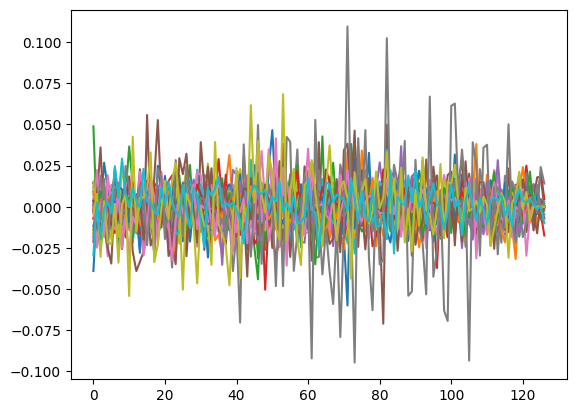

In [11]:
for i in range(40):
    plt.plot(log_returns[i])

In [12]:
print("NaNs remaining:", np.isnan(log_returns).sum())

NaNs remaining: 0


In [13]:
# np.save('./data/mean-var/split_paths_log_return.npy', log_returns)

# Eval

In [14]:
def compute_mmd(x, y):
    """
    Computes Maximum Mean Discrepancy (MMD) using RBF kernel with NumPy.
    
    Args:
        x (np.array): Real data samples, shape (n_samples, n_features)
        y (np.array): Generated data samples, shape (m_samples, n_features)
        
    Returns:
        float: The MMD score (lower is better, 0 means identical distributions)
    """
    # Ensure inputs are numpy arrays
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 1. Compute Pairwise Squared Euclidean Distances
    # We use broadcasting: (N, 1, D) - (1, N, D) results in (N, N, D)
    # Summing over the last axis (D) gives us the squared Euclidean distance
    xx_dist = np.sum((x[:, None, :] - x[None, :, :])**2, axis=-1)
    yy_dist = np.sum((y[:, None, :] - y[None, :, :])**2, axis=-1)
    xy_dist = np.sum((x[:, None, :] - y[None, :, :])**2, axis=-1)

    # 2. Estimate Bandwidth (Sigma) using Median Heuristic
    # We use the median distance between X and Y to set the "width" of the kernel.
    # This makes the metric scale-invariant.
    sigma2 = np.median(xy_dist)
    
    # Avoid division by zero if datasets are identical
    if sigma2 == 0: 
        sigma2 = 1.0

    # 3. Compute MMD using a Multi-Scale Kernel
    mmd_score = 0.0
    scales = [0.5, 1.0, 2.0]  # Look at small, medium, and large features
    
    for scale in scales:
        gamma = 1.0 / (scale * sigma2 + 1e-10)
        
        # RBF Kernel: K(x,y) = exp(-gamma * ||x-y||^2)
        k_xx = np.exp(-gamma * xx_dist)
        k_yy = np.exp(-gamma * yy_dist)
        k_xy = np.exp(-gamma * xy_dist)
        
        # MMD^2 = E[K_xx] + E[K_yy] - 2E[K_xy]
        mmd_score += k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()
        
    return mmd_score

def compute_metrics(real_returns, gen_returns, bins=10):
    """
    real_returns: np.array of shape (40, 126)
    gen_returns: np.array of shape (40, 126)
    """
    
    # 1. MMD on Full Paths (Temporal Correlation check)
    # Convert to tensors for MMD
    real_t = torch.tensor(real_returns, dtype=torch.float32)
    gen_t = torch.tensor(gen_returns, dtype=torch.float32)
    mmd_score = compute_mmd(real_t, gen_t)
    
    # 2. Wasserstein-2 on Flattened Marginals (Distributional shape check)
    # We use sqrt(W_2^2) -> usually scipy implements W_1, 
    # but for 1D, W_2 is just Euclidean distance between sorted vectors.
    real_flat = real_returns.flatten()
    gen_flat = gen_returns.flatten()
    
    # Manual 1D W-2 calculation:
    # Sort both distributions
    r_sorted = np.sort(real_flat)
    g_sorted = np.sort(gen_flat)
    # If sizes differ, interpolation is needed, but here sizes are equal (40*126)
    w2_dist = np.sqrt(np.mean((r_sorted - g_sorted)**2))
    
    # 3. KL Divergence on Volatility (Stylized Fact check)
    # Extract volatility (std dev) per path
    real_vol = np.std(real_returns, axis=1)
    gen_vol = np.std(gen_returns, axis=1)
    
    # We use the same bins for both to ensure alignment
    # Get the range from both datasets to ensure coverage
    min_val = min(real_vol.min(), gen_vol.min())
    max_val = max(real_vol.max(), gen_vol.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    count_r, _ = np.histogram(real_vol, bins=bin_edges, density=False)
    count_g, _ = np.histogram(gen_vol, bins=bin_edges, density=False)

    # 3. Add Epsilon (Smoothing)
    # This prevents division by zero. 1e-10 is small enough not to skew results.
    epsilon = 1e-10
    prob_r = count_r + epsilon
    prob_g = count_g + epsilon
    
    # 2. Convert to Probability MASS (Sum = 1)
    prob_r = prob_r / prob_r.sum()
    prob_g = prob_g / prob_g.sum()
    
    kl_div = entropy(prob_r, prob_g)
    
    # 4. Total Variation (TV)
    tv_dist = 0.5 * np.sum(np.abs(prob_r - prob_g))
    
    return {
        "MMD (Pathwise)": mmd_score,
        "W2 (Marginal)": w2_dist,
        "KL (Volatility)": kl_div,
        "TV (Volatility)": tv_dist
    }

In [15]:
# load training samples
train_data = np.load('./data/mean-var/split_paths_log_return.npy')

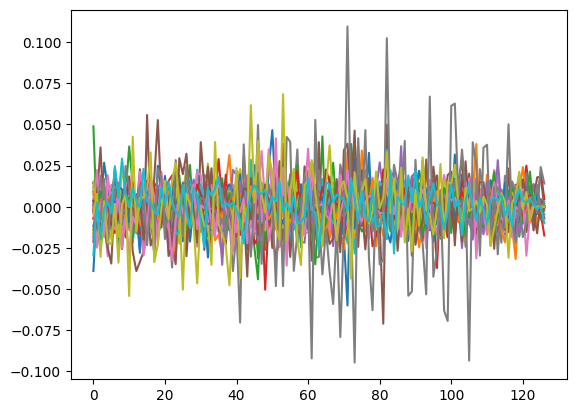

In [16]:
for i in range(40):
    plt.plot(train_data[i])

In [35]:
train_acfs = []
train_pacfs = []

for row in train_data:
    train_acfs.append(acf(row, nlags=59, fft=True))
    train_pacfs.append(pacf(row, nlags=19))

train_acfs = np.array(train_acfs)
train_pacfs = np.array(train_pacfs)

# Mean and Confidence Interval (1 std dev)
train_mean_acf = train_acfs.mean(axis=0)
train_std_acf = train_acfs.std(axis=0)

train_mean_pacf = train_pacfs.mean(axis=0)
train_std_pacf = train_pacfs.std(axis=0)

In [36]:
# load generated samples
gen_data = np.load('/home/yinbinha/adapted_diffusion_model/samples/dfm_split_paths_log_return_ts1767163517_seed42' + '/sample_batch1.npy')

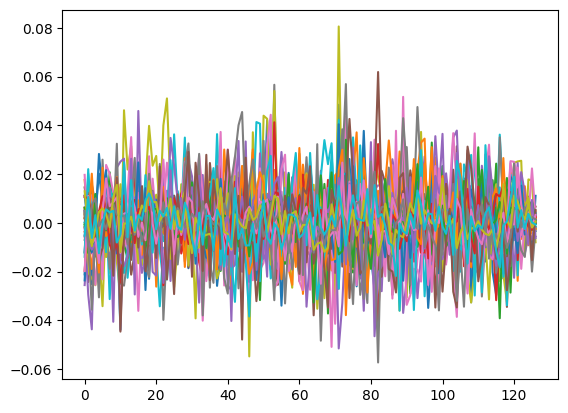

In [37]:
for i in range(40):
    plt.plot(gen_data[i])

In [38]:
# --- 2. Empirical (Generated) ---
# Compute ACF/PACF for every single path
gen_acfs = []
gen_pacfs = []

for row in gen_data:
    gen_acfs.append(acf(row, nlags=59, fft=True))
    gen_pacfs.append(pacf(row, nlags=19))
    
gen_acfs = np.array(gen_acfs)
gen_pacfs = np.array(gen_pacfs)

# Mean and Confidence Interval (1 std dev)
gen_mean_acf = gen_acfs.mean(axis=0)
gen_std_acf = gen_acfs.std(axis=0)

gen_mean_pacf = gen_pacfs.mean(axis=0)
gen_std_pacf = gen_pacfs.std(axis=0)

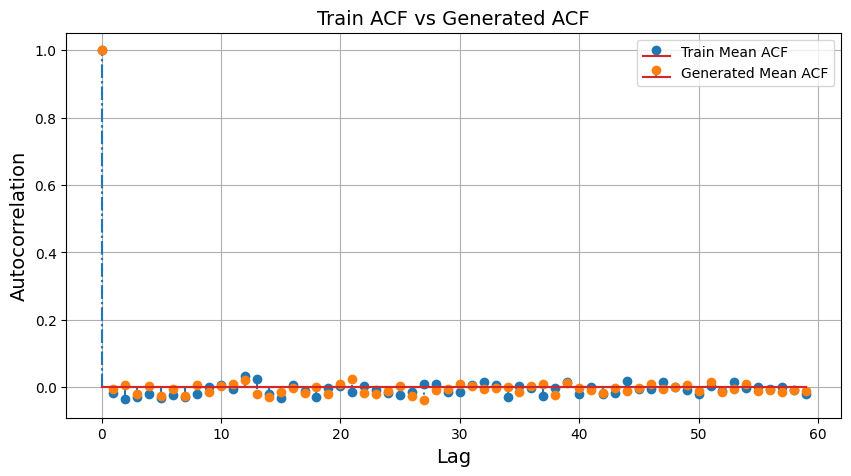

In [39]:
lags_range = np.arange(len(train_mean_acf))

plt.figure(figsize=(10, 5))

# # True ACF (solid line)
# # plt.plot(lags_range, theo_acf, label="True ARMA ACF", linewidth=2)
# markerline, stemlines, baseline = plt.stem(lags_range, theo_acf, label="True ARMA ACF", linefmt="-")


# Mean synthetic ACF (dashed line)
# plt.plot(lags_range, train_mean_acf, label="Sample Mean ACF", linestyle='--', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, train_mean_acf, label="Train Mean ACF", linefmt="-.")

# plt.plot(lags_range, mean_acf, label="Generated Mean ACF", linestyle='-.', linewidth=2)
markerline, stemlines, baseline = plt.stem(lags_range, gen_mean_acf, label="Generated Mean ACF", linefmt=":")



# # Optional: 1 std confidence band around generated ACF
# plt.fill_between(
#     lags_range,
#     gen_mean_acf - gen_std_acf,
#     gen_mean_acf + gen_std_acf,
#     alpha=0.2,
#     label="Generated ACF ± 1 std"
# )

plt.xlabel("Lag", fontsize=14)
plt.ylabel("Autocorrelation", fontsize=14)
# plt.title("True ACF vs Sample ACF vs Generated ACF", fontsize=14)
plt.title("Train ACF vs Generated ACF", fontsize=14)
plt.legend()
plt.grid(True)

# plt.savefig('ACF_H500_N512.png', dpi=300, bbox_inches='tight')

plt.show()

In [40]:
np.linalg.norm(gen_mean_acf - train_mean_acf, ord=2) / np.linalg.norm(train_mean_acf, ord=2)

0.14438534398992733

In [41]:
np.linalg.norm(gen_mean_acf - train_mean_acf, ord=1) / np.linalg.norm(train_mean_acf, ord=1)

0.5031850211921226

In [42]:
compute_metrics(train_data, gen_data)

{'MMD (Pathwise)': 0.09678995609283447,
 'W2 (Marginal)': 0.0020526014633727705,
 'KL (Volatility)': 0.8241961404167105,
 'TV (Volatility)': 0.274999999993125}